# Notebook 04: Visualización Espacial y Segmentación Ecuatorial
**Autor:** Iván Andrés Mena Contreras
**Proyecto:** Lunar Tidal Triggering of Earthquakes

En el cuaderno anterior confirmamos que, a escala global, los grandes sismos ($M \geq 7.0$) se distribuyen como ruido respecto a las fases lunares ($p pprox 0.45$). 

**Objetivo de este Cuaderno:**
Aislar la señal lunar cruzando la fase lunar con la ubicación geográfica. Al calcular el Punto Sublunar y segmentar geográficamente (específicamente en el cinturón de subducción ecuatorial, entre latitudes -30° y +30°), buscamos detectar si la marea de la corteza, que es máxima en el ecuador terrestre, actúa como gatillo regional.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import os
from astropy.time import Time
from astropy.coordinates import get_sun, get_body, EarthLocation, AltAz
from astropy import units as u

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Crear directorios
os.makedirs('../results/maps', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

# Carga de datos limpios
data_path = '../data/processed/earthquakes_with_moon_final.csv'
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'], format='mixed')

print(f"Catálogo cargado: {len(df)} eventos.")

Catálogo cargado: 335 eventos.


## 1. Visualización Espacial Global
Graficamos todos los epicentros para comprender la distribución tectónica de nuestro catálogo.

In [2]:
# Función para determinar color según profundidad
def color_profundidad(prof):
    if prof <= 20: return '#e74c3c'  # Rojo (Superficial)
    elif prof <= 45: return '#f39c12' # Naranja (Intermedio)
    return '#2980b9'                  # Azul (Profundo)

# Crear mapa base
mapa = folium.Map(location=[0, 0], zoom_start=2, tiles='CartoDB dark_matter')

for idx, row in df.iterrows():
    # El radio depende de la magnitud
    radio = np.exp(row['magnitude'] - 6.5) * 2
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radio,
        color=color_profundidad(row['depth']),
        fill=True,
        fill_color=color_profundidad(row['depth']),
        fill_opacity=0.7,
        tooltip=f"M{row['magnitude']} - {row['place']} (Prof: {row['depth']}km)"
    ).add_to(mapa)

map_path = '../results/maps/04_epicenters_map.html'
mapa.save(map_path)
print(f"Mapa global guardado en: {map_path}")
mapa

Mapa global guardado en: ../results/maps/04_epicenters_map.html


## 2. Cálculo del Punto Sublunar
El "Punto Sublunar" es el lugar geográfico exacto en la Tierra donde la Luna se encontraba exactamente en el cenit (arriba en el cielo) en el momento preciso de la ruptura del sismo.

La Latitud del punto sublunar es igual a la Declinación de la Luna (`moon_dec`).
La Longitud depende del Tiempo Sideral Aparente de Greenwich (GAST) y la Ascensión Recta (`moon_ra`).

In [3]:
# Astropy Time object
tiempos = Time(df['time'])

# Calcular el GAST (Greenwich Apparent Sidereal Time)
gast = tiempos.sidereal_time('apparent', 'greenwich')

# La longitud del punto sublunar es: moon_ra - gast
# (Convirtiendo todo a grados y normalizando entre -180 y +180)
lon_sublunar = (df['moon_ra'] - gast.degree + 180) % 360 - 180

# Asignar al DataFrame
df['sublunar_lat'] = df['moon_dec']
df['sublunar_lon'] = lon_sublunar

print("Cálculo del punto sublunar completado.")
df[['time', 'latitude', 'longitude', 'sublunar_lat', 'sublunar_lon']].head()

Cálculo del punto sublunar completado.


,time,latitude,longitude,sublunar_lat,sublunar_lon
0,1995-01-06 22:37:34.320000+00:00,40.246,142.175,2.06087,-89.868627
1,1995-02-05 22:51:05.140000+00:00,-37.759,178.752,12.09037,-91.351617
2,1995-04-07 22:06:56.890000+00:00,-15.199,-173.529,17.80052,-62.535275
3,1995-04-21 00:34:46.090000+00:00,12.059,125.580,-17.52783,69.424917
4,1995-05-05 03:53:45.050000+00:00,12.626,125.297,17.88158,-176.845705


## 3. Distancia Angular al Punto Sublunar
Calculamos la distancia ortodrómica (o ángulo central) entre el epicentro y el punto sublunar usando trigonometría esférica.

Histograma guardado en: ../results/figures/04_angular_dist.png


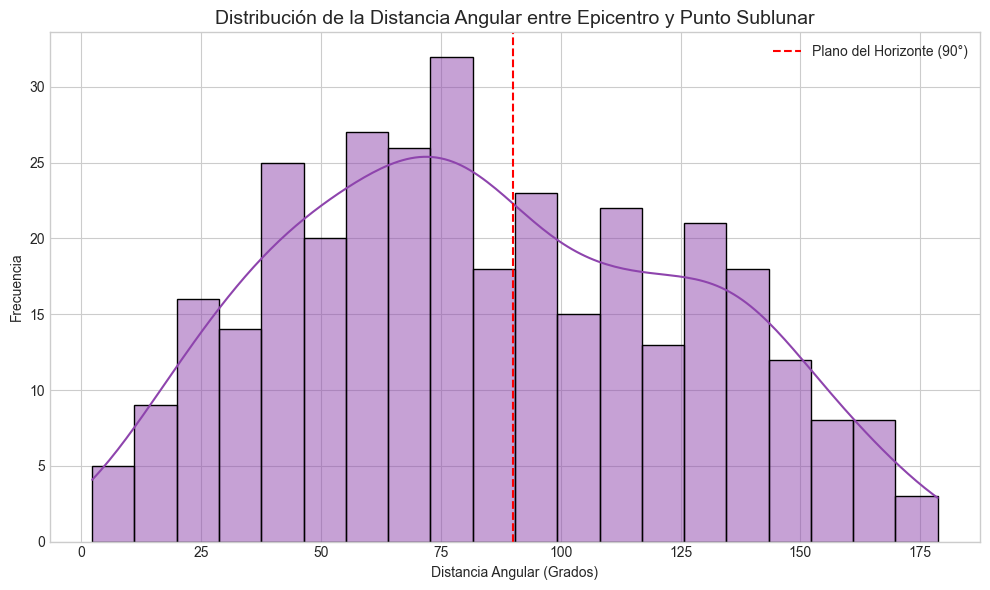

In [4]:
def distancia_angular(lat1, lon1, lat2, lon2):
    """Calcula la distancia angular en grados entre dos puntos en una esfera."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Ley esférica de los cosenos
    d_sigma = np.arccos(
        np.sin(lat1) * np.sin(lat2) + 
        np.cos(lat1) * np.cos(lat2) * np.cos(abs(lon1 - lon2))
    )
    return np.degrees(d_sigma)

# Calcular distancias
df['angular_distance'] = distancia_angular(
    df['latitude'], df['longitude'], 
    df['sublunar_lat'], df['sublunar_lon']
)

# Visualizar distribución
plt.figure(figsize=(10, 6))
sns.histplot(df['angular_distance'], bins=20, kde=True, color='#8e44ad')
plt.axvline(90, color='red', linestyle='--', label='Plano del Horizonte (90°)')
plt.title('Distribución de la Distancia Angular entre Epicentro y Punto Sublunar', fontsize=14)
plt.xlabel('Distancia Angular (Grados)')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()

dist_path = '../results/figures/04_angular_dist.png'
plt.savefig(dist_path, dpi=300)
print(f"Histograma guardado en: {dist_path}")
plt.show()

## 4. Filtro Ecuatorial Regional
La fuerza de marea sólida de la Tierra es mayor en el ecuador. Vamos a aislar nuestra búsqueda de señal filtrando exclusivamente sismos superficiales ($<20$ km) dentro de las latitudes bajas ($-30^{\circ}$ a $+30^{\circ}$).

In [5]:
# Filtrar Sismos Superficiales y Ecuatoriales
condicion_profundidad = df['depth'] < 20
condicion_latitud = (df['latitude'] >= -30) & (df['latitude'] <= 30)

df_ecuatorial = df[condicion_profundidad & condicion_latitud].copy()

print(f"Sismos originales en el catálogo: {len(df)}")
print(f"Sismos en el Cinturón Ecuatorial Superficial: {len(df_ecuatorial)}")

Sismos originales en el catálogo: 335
Sismos en el Cinturón Ecuatorial Superficial: 56


## 5. Test de Schuster Regional
Recalculamos el valor $p$ utilizando únicamente este nuevo sub-grupo altamente susceptible a la fuerza de marea cortical máxima.

In [6]:
def schuster_test(angulos_deg):
    """Calcula el p-value del Test de Schuster basado en ángulos en grados."""
    angulos_rad = np.radians(angulos_deg)
    N = len(angulos_rad)
    if N == 0: return np.nan, np.nan
    
    R = np.sqrt(np.sum(np.cos(angulos_rad))**2 + np.sum(np.sin(angulos_rad))**2)
    p_value = np.exp(-(R**2) / N)
    return R, p_value

# Extraer el ángulo de fase lunar que usamos en el Nb 03
# Fase = (RA Luna - RA Sol)
sol = get_sun(Time(df_ecuatorial['time']))
luna = get_body('moon', Time(df_ecuatorial['time']))
fase_lunar = np.mod(luna.ra.degree - sol.ra.degree, 360)

# Calcular Schuster
R_reg, p_reg = schuster_test(fase_lunar)

print("=== TEST DE SCHUSTER REGIONAL (ECUATORIAL SUPERFICIAL) ===")
print(f"  N = {len(df_ecuatorial)}")
print(f"  Vector R: {R_reg:.4f}")
print(f"  p-value:  {p_reg:.5f}")

if p_reg < 0.05:
    print("  -> ¡CONCLUSIÓN: Se rechaza la hipótesis nula! Hay una correlación ESTADÍSTICAMENTE SIGNIFICATIVA con la fase lunar en esta región.")
else:
    print("  -> CONCLUSIÓN: No se rechaza la hipótesis nula. El subgrupo regional sigue comportándose como ruido estadístico.")

=== TEST DE SCHUSTER REGIONAL (ECUATORIAL SUPERFICIAL) ===
  N = 56
  Vector R: 8.0645
  p-value:  0.31306
  -> CONCLUSIÓN: No se rechaza la hipótesis nula. El subgrupo regional sigue comportándose como ruido estadístico.


## 6. Exportar Datos
Guardamos este subset de alto interés para posibles cruces de datos con fallas tectónicas específicas en el siguiente cuaderno.

In [7]:
export_path = '../data/processed/earthquakes_ecuatorial_subset.csv'
df_ecuatorial.to_csv(export_path, index=False)
print(f"Subset exportado exitosamente a: {export_path}")

Subset exportado exitosamente a: ../data/processed/earthquakes_ecuatorial_subset.csv
